# Step 3: The time-dependent model and the grid-resolution problem

Does my model, run forward in time until it stops changing, put the grounding line where Schoof's theory says it should be? And how does the answer depend on the grid spacing? I add mass conservation to the velocity solver of step 2, run one case to steady state at grid spacings from 8 km to 0.5 km, and compare with Schoof's prediction. Then I add a simple sub-grid treatment of the grounding line and repeat.

I load the libraries and model functions, and set the parameters. The rate factor is the first MISMIP value, A = 3e-25 Pa^-3 s^-1. In step 1 it has a single steady state, on a part of the bed that deepens normally toward the ocean, away from the overdeepening. Units: metres and years.

In [1]:
%matplotlib inline

import os
import time

import numpy as np
import matplotlib.pyplot as plt

from flowline import (RHO_I, RHO_W, ACCUMULATION, a_per_year, bed, flotation_thickness, make_grid,
                      surface_elevation, grounded_fraction_edges, grounding_line_position, edge_flux,
                      stable_time_step, run_to_steady_state, schoof_steady_positions, solve_ssa)

A_SI = 3e-25                  # rate factor (Pa^-3 s^-1): MISMIP EXP 3 step 1
A_YR = a_per_year(A_SI)       # the same in Pa^-3 yr^-1
X_CALVING = 1600e3            # fixed calving front (m), chosen in step 1
H_INITIAL = 10.0              # starting thickness everywhere (m), as in MISMIP: a thin layer of ice
DX_LIST = [8e3, 4e3, 2e3, 1e3, 0.5e3]   # grid spacings (m)
MAX_YEARS = 60000.0           # longest run allowed (yr)
CHECK_EVERY = 500.0           # how often to test for steady state (yr)
XG_RATE_TOL = 0.1             # steady when the grounding line moves less than this (m/yr) ...
DHDT_TOL = 1e-4               # ... and the thickness changes less than this on average (m/yr)
CFL = 0.5                     # time step: ice moves at most half a cell per step
DT_MAX = 10.0                 # and never more than 10 years per step
FIG_DIR = "../figures"
DATA_DIR = "../data"

## Mass conservation, the time step, and grounded or floating

Ice thickness changes because of snowfall and because ice flows in and out of each cell:

dH/dt = a - d(uH)/dx

I update each cell with H_new = H + dt (a - (flux out - flux in)/dx), where the flux u H lives at the cell edges. For H at an edge I take the value of the cell the ice comes FROM (upwind). Using the average of the two neighbours instead would let small wiggles grow, because a cell's thickness would then partly depend on ice that has not reached it yet.

The time-step rule: an explicit update is only stable if no ice moves more than one cell in a step, dt < dx / max|u|. I use half of that (CFL = 0.5), capped at 10 years. So the fastest ice, at the calving front, sets the step, and halving dx halves dt.

Grounded or floating: in each cell the ice is grounded if it is thicker than the flotation thickness, H > -(rho_w/rho_i) b. The surface is then b + H on grounded ice and (1 - rho_i/rho_w) H on floating ice. Friction acts only on the grounded part. I start, as in MISMIP, from a 10 m layer of ice everywhere, and here I show the first 2000 years on the 8 km grid.

In [2]:
dx = 8e3
x_edges, x_centres = make_grid(X_CALVING, dx)
h0 = np.full(len(x_centres), H_INITIAL)
print(f"{len(x_centres)} cells; 10 m ice floats where the bed is below {-H_INITIAL * RHO_I / RHO_W:.0f} m; "
      f"starting grounding line {grounding_line_position(h0, x_centres) / 1e3:.1f} km")
first = run_to_steady_state(h0, x_centres, dx, A_YR, "plain", max_years=2000.0, check_every=500.0,
                            xg_rate_tol=-1.0, cfl=CFL, dt_max=DT_MAX, verbose=True)
print(f"{first['steps']} time steps in 2000 years, so about {2000.0 / first['steps']:.1f} years per step; "
      f"fastest ice now {first['u'].max():.0f} m/yr")

200 cells; 10 m ice floats where the bed is below -9 m; starting grounding line 481.6 km
t =      500 yr | x_g =   535.10 km | |dx_g/dt| =  107.031 m/yr | mean |dH/dt| = 2.91e-01 m/yr
t =     1000 yr | x_g =   558.09 km | |dx_g/dt| =   45.983 m/yr | mean |dH/dt| = 1.93e-01 m/yr
t =     1500 yr | x_g =   564.44 km | |dx_g/dt| =   12.707 m/yr | mean |dH/dt| = 1.16e-01 m/yr
t =     2000 yr | x_g =   565.52 km | |dx_g/dt| =    2.157 m/yr | mean |dH/dt| = 1.04e-01 m/yr
486 time steps in 2000 years, so about 4.1 years per step; fastest ice now 1363 m/yr


## Schoof's prediction for this A

From step 1, the only steady grounding line for A = 3e-25 is on the normal part of the bed.

In [3]:
states = schoof_steady_positions(A_YR, 480e3, 1800e3)
x_schoof = [xg for xg, stable in states if stable][0]
print(f"Schoof steady states: {[(round(xg / 1e3, 1), bool(st)) for xg, st in states]}")
print(f"target grounding line: {x_schoof / 1e3:.2f} km (bed {bed(x_schoof):.1f} m)")

Schoof steady states: [(721.9, True)]
target grounding line: 721.90 km (bed -530.2 m)


## The plain fixed grid

First the plain scheme: an edge counts as grounded (full friction) or floating (no friction) depending on the average thickness above flotation of its two neighbouring cells. Each run starts from the 10 m layer and runs until the grounding line moves less than 0.1 m/yr and the thickness changes less than 0.1 mm/yr on average over 500 years. The grounding-line position I report is where the thickness above flotation crosses zero, interpolated between the two cells on either side, so it is not limited to the grid points.

In [4]:
def run_case(dx, scheme, a_yr=A_YR, h_start=None):
    x_edges, x_centres = make_grid(X_CALVING, dx)
    if h_start is None:
        h_start = np.full(len(x_centres), H_INITIAL)
    start = time.time()
    result = run_to_steady_state(h_start, x_centres, dx, a_yr, scheme, max_years=MAX_YEARS, check_every=CHECK_EVERY,
                                 xg_rate_tol=XG_RATE_TOL, dhdt_tol=DHDT_TOL, cfl=CFL, dt_max=DT_MAX)
    result["wall_time"] = time.time() - start
    result["x_centres"] = x_centres
    result["x_edges"] = x_edges
    result["dx"] = dx
    return result

results = {}
for dx in DX_LIST:
    r = run_case(dx, "plain")
    results[("plain", dx)] = r
    print(f"plain   dx = {dx / 1e3:4.1f} km: x_g = {r['x_g'][-1] / 1e3:7.2f} km (Schoof {x_schoof / 1e3:.2f}, "
          f"error {(r['x_g'][-1] - x_schoof) / 1e3:+7.2f} km) | steady {r['steady']} after {r['years']:.0f} yr | "
          f"{r['steps']} steps | {r['wall_time']:.1f} s")

plain   dx =  8.0 km: x_g =  615.44 km (Schoof 721.90, error -106.45 km) | steady True after 18500 yr | 7943 steps | 3.1 s


plain   dx =  4.0 km: x_g =  639.79 km (Schoof 721.90, error  -82.10 km) | steady True after 20000 yr | 17180 steps | 7.0 s


plain   dx =  2.0 km: x_g =  659.94 km (Schoof 721.90, error  -61.96 km) | steady True after 21000 yr | 36042 steps | 16.8 s


plain   dx =  1.0 km: x_g =  676.99 km (Schoof 721.90, error  -44.91 km) | steady True after 21000 yr | 71529 steps | 45.2 s


plain   dx =  0.5 km: x_g =  691.50 km (Schoof 721.90, error  -30.40 km) | steady True after 21500 yr | 146230 steps | 136.9 s


## Why a plain fixed grid struggles

Two things go wrong at the grounding line on a fixed grid:

1. Friction switches off abruptly. On one side of an edge the ice has full basal friction, on the other none. The true change happens over a short distance (Schoof's boundary layer), and on a coarse grid that distance is far smaller than one cell.
2. The grounding line can only move one whole cell at a time. To move from one edge to the next, the cell just seaward of the grounding line has to thicken until it grounds, and until then nothing changes in the friction. So the grounding line tends to get stuck where the flux has to rise a lot before the next cell can ground, and the coarser the grid, the bigger that step is.

## A simple sub-grid scheme

The fix I try follows Gladstone et al. (2010) and Leguy et al. (2014). The thickness above flotation, H - H_f, is positive on grounded ice and negative on floating ice. Between the last grounded and the first floating cell centre I place the grounding line where a straight line between the two values crosses zero. The edge between them then gets friction multiplied by the fraction of its stretch (centre to centre) that is grounded. As the ice thickens, the grounding line, and the friction, move smoothly instead of in jumps of one cell.

In [5]:
x_demo = np.array([600e3, 608e3, 616e3, 624e3, 632e3])                          # five cell centres, 8 km apart (m)
h_demo = flotation_thickness(x_demo) + np.array([60.0, 25.0, -15.0, -40.0, -60.0])  # 60 m above flotation ... 60 m below
print("thickness above flotation at five centres (m):", np.round(h_demo - flotation_thickness(x_demo), 1))
print("plain scheme, friction fraction at the edges between them:  ", grounded_fraction_edges(h_demo, x_demo, "plain")[1:-1])
print("sub-grid scheme, friction fraction at the edges between them:", np.round(grounded_fraction_edges(h_demo, x_demo, "subgrid")[1:-1], 3))
print(f"interpolated grounding line: {grounding_line_position(h_demo, x_demo) / 1e3:.2f} km "
      f"(25 / (25 + 15) = {25 / 40:.3f} of the way from 608 to 616 km)")

thickness above flotation at five centres (m): [ 60.  25. -15. -40. -60.]
plain scheme, friction fraction at the edges between them:   [1. 1. 0. 0.]
sub-grid scheme, friction fraction at the edges between them: [1.    0.625 0.    0.   ]
interpolated grounding line: 613.00 km (25 / (25 + 15) = 0.625 of the way from 608 to 616 km)


The same resolution test with the sub-grid scheme.

In [6]:
for dx in DX_LIST:
    r = run_case(dx, "subgrid")
    results[("subgrid", dx)] = r
    print(f"subgrid dx = {dx / 1e3:4.1f} km: x_g = {r['x_g'][-1] / 1e3:7.2f} km (Schoof {x_schoof / 1e3:.2f}, "
          f"error {(r['x_g'][-1] - x_schoof) / 1e3:+7.2f} km) | steady {r['steady']} after {r['years']:.0f} yr | "
          f"{r['steps']} steps | {r['wall_time']:.1f} s")

subgrid dx =  8.0 km: x_g =  691.84 km (Schoof 721.90, error  -30.06 km) | steady True after 20000 yr | 8421 steps | 3.5 s


subgrid dx =  4.0 km: x_g =  705.78 km (Schoof 721.90, error  -16.11 km) | steady True after 22000 yr | 18723 steps | 8.0 s


subgrid dx =  2.0 km: x_g =  710.98 km (Schoof 721.90, error  -10.92 km) | steady True after 21500 yr | 36291 steps | 17.4 s


subgrid dx =  1.0 km: x_g =  715.48 km (Schoof 721.90, error   -6.42 km) | steady True after 22000 yr | 74438 steps | 43.7 s


subgrid dx =  0.5 km: x_g =  717.73 km (Schoof 721.90, error   -4.16 km) | steady True after 22500 yr | 152782 steps | 111.5 s


A table of all runs, saved to `data/resolution_test.csv`, and the error against grid spacing on log-log axes. A straight line with slope p means the error shrinks like dx^p.

scheme    dx (km)  x_g (km)  error (km)   years   steps  time (s)
plain         8.0    615.44     -106.45   18500    7943       3.1
plain         4.0    639.79      -82.10   20000   17180       7.0
plain         2.0    659.94      -61.96   21000   36042      16.8
plain         1.0    676.99      -44.91   21000   71529      45.2
plain         0.5    691.50      -30.40   21500  146230     136.9
subgrid       8.0    691.84      -30.06   20000    8421       3.5
subgrid       4.0    705.78      -16.11   22000   18723       8.0
subgrid       2.0    710.98      -10.92   21500   36291      17.4
subgrid       1.0    715.48       -6.42   22000   74438      43.7
subgrid       0.5    717.73       -4.16   22500  152782     111.5
plain: error shrinks like dx^0.45; between neighbouring spacings: [0.37 0.41 0.46 0.56]
subgrid: error shrinks like dx^0.70; between neighbouring spacings: [0.9  0.56 0.77 0.63]


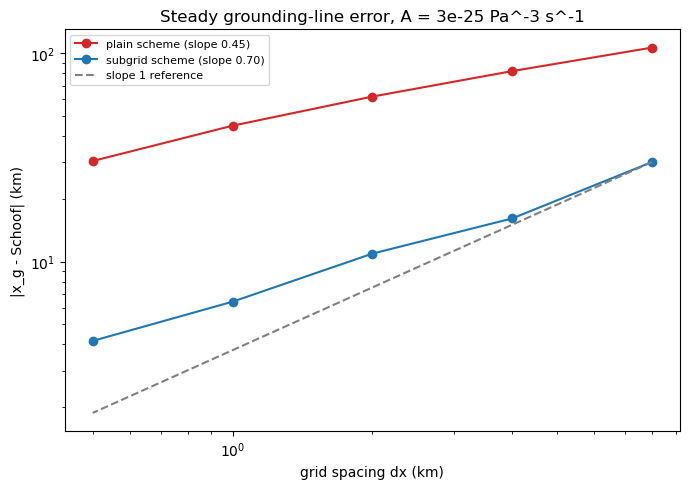

In [7]:
rows = []
for scheme in ["plain", "subgrid"]:
    for dx in DX_LIST:
        r = results[(scheme, dx)]
        rows.append((scheme, dx, r["x_g"][-1], r["x_g"][-1] - x_schoof, r["years"], r["steps"], r["wall_time"], r["steady"]))
with open(os.path.join(DATA_DIR, "resolution_test.csv"), "w") as f:
    f.write("scheme,dx_km,x_g_km,error_km,years_to_steady,time_steps,run_time_s,steady\n")
    for scheme, dx, xg, err, years, steps, wall, steady in rows:
        f.write(f"{scheme},{dx / 1e3},{xg / 1e3:.3f},{err / 1e3:.3f},{years:.0f},{steps},{wall:.2f},{steady}\n")

print(f"{'scheme':8s} {'dx (km)':>8s} {'x_g (km)':>9s} {'error (km)':>11s} {'years':>7s} {'steps':>7s} {'time (s)':>9s}")
for scheme, dx, xg, err, years, steps, wall, steady in rows:
    print(f"{scheme:8s} {dx / 1e3:8.1f} {xg / 1e3:9.2f} {err / 1e3:+11.2f} {years:7.0f} {steps:7d} {wall:9.1f}")

dx_km = np.array(DX_LIST) / 1e3
fig, ax = plt.subplots(figsize=(7, 5))
for scheme, color in [("plain", "tab:red"), ("subgrid", "tab:blue")]:
    err = np.array([abs(results[(scheme, dx)]["x_g"][-1] - x_schoof) / 1e3 for dx in DX_LIST])
    p, logc = np.polyfit(np.log(dx_km), np.log(err), 1)
    print(f"{scheme}: error shrinks like dx^{p:.2f}; between neighbouring spacings: "
          f"{np.round(np.diff(np.log(err)) / np.diff(np.log(dx_km)), 2)}")
    ax.loglog(dx_km, err, "o-", color=color, label=f"{scheme} scheme (slope {p:.2f})")
ax.loglog(dx_km, abs(results[("subgrid", DX_LIST[0])]["x_g"][-1] - x_schoof) / 1e3 * (dx_km / dx_km[0]), color="0.5", ls="--",
          label="slope 1 reference")
ax.set_xlabel("grid spacing dx (km)")
ax.set_ylabel("|x_g - Schoof| (km)")
ax.set_title(f"Steady grounding-line error, A = {A_SI:.0e} Pa^-3 s^-1")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "03_resolution_error.png"), dpi=150)
plt.show()

The grounding line against time for every run. All start at the same place and advance as the ice sheet builds up; the coarse plain-grid runs stop early.

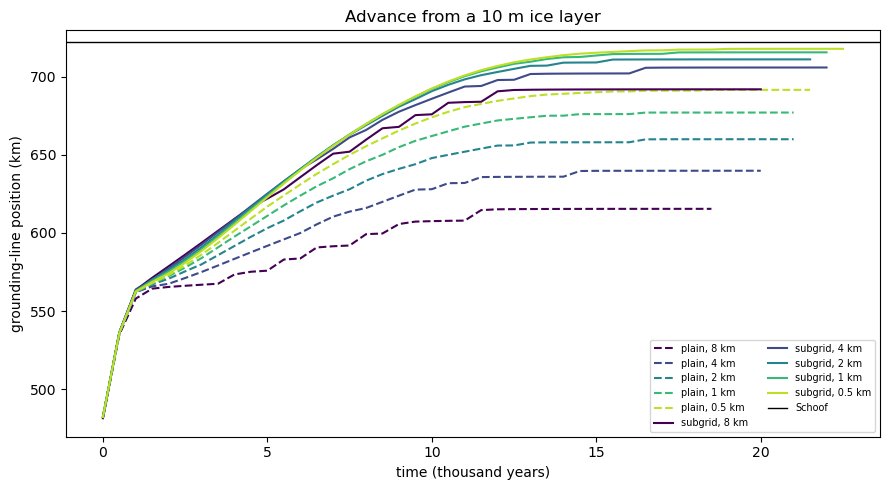

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(DX_LIST)))
for scheme, style in [("plain", "--"), ("subgrid", "-")]:
    for dx, color in zip(DX_LIST, colors):
        r = results[(scheme, dx)]
        ax.plot(r["time"] / 1e3, r["x_g"] / 1e3, style, color=color, label=f"{scheme}, {dx / 1e3:g} km")
ax.axhline(x_schoof / 1e3, color="k", lw=1, label="Schoof")
ax.set_xlabel("time (thousand years)")
ax.set_ylabel("grounding-line position (km)")
ax.set_title("Advance from a 10 m ice layer")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "03_gl_vs_time.png"), dpi=150)
plt.show()

The steady ice profiles: surface, ice base and bed for the coarsest and finest grids with each scheme, and a close-up near the grounding line.

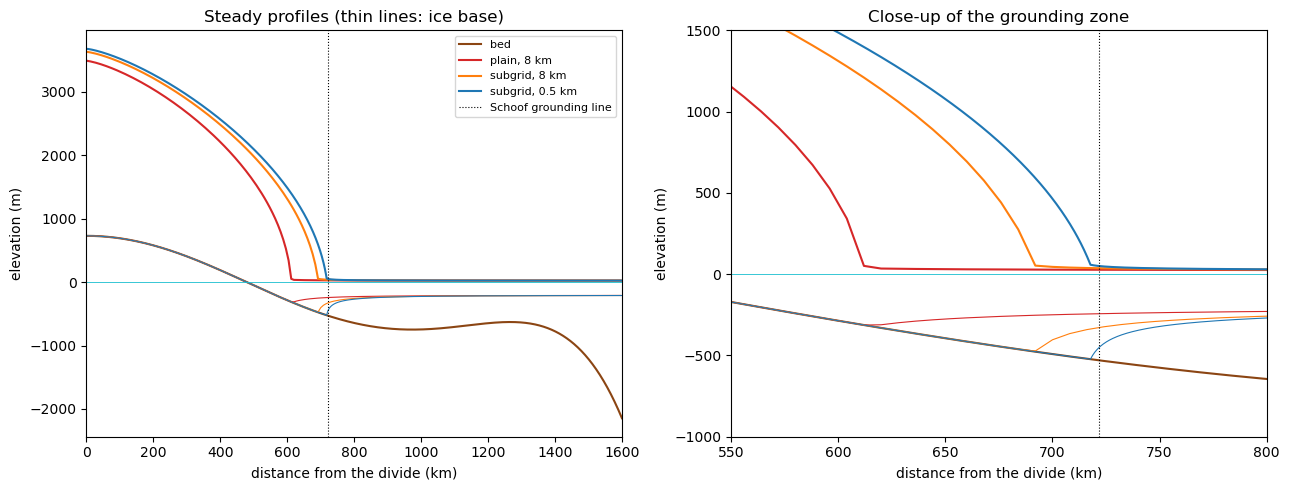

finest sub-grid run: thickest ice 2948 m, fastest ice 2037 m/yr at the calving front


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, xlim in zip(axes, [(0, X_CALVING / 1e3), (550, 800)]):
    xb = np.linspace(0, X_CALVING, 1601)
    ax.plot(xb / 1e3, bed(xb), color="saddlebrown", label="bed")
    for key, color in [(("plain", DX_LIST[0]), "tab:red"), (("subgrid", DX_LIST[0]), "tab:orange"), (("subgrid", DX_LIST[-1]), "tab:blue")]:
        r = results[key]
        s = surface_elevation(r["h"], bed(r["x_centres"]))
        ax.plot(r["x_centres"] / 1e3, s, color=color, label=f"{key[0]}, {key[1] / 1e3:g} km")
        ax.plot(r["x_centres"] / 1e3, s - r["h"], color=color, lw=0.8)
    ax.axvline(x_schoof / 1e3, color="k", lw=0.8, ls=":", label="Schoof grounding line")
    ax.axhline(0, color="tab:cyan", lw=0.6)
    ax.set_xlim(*xlim)
    ax.set_xlabel("distance from the divide (km)")
    ax.set_ylabel("elevation (m)")
axes[0].set_title("Steady profiles (thin lines: ice base)")
axes[1].set_title("Close-up of the grounding zone")
axes[1].set_ylim(-1000, 1500)
axes[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "03_steady_profiles.png"), dpi=150)
plt.show()
r = results[("subgrid", DX_LIST[-1])]
print(f"finest sub-grid run: thickest ice {r['h'].max():.0f} m, fastest ice {r['u'].max():.0f} m/yr at the calving front")

## An extra check: does a coarse grid end in the same place when the grounding line retreats?

So far every run advanced into its steady state. If the grid itself can hold the grounding line in place, a run that retreats into the same A should stop somewhere else. For the three coarsest grids I first run to steady state with A = 1e-25 (Schoof: 799.8 km, on the normal part of the bed), then switch to A = 3e-25 and let the grounding line retreat.

In [10]:
retreat = {}
for scheme in ["plain", "subgrid"]:
    for dx in DX_LIST[:3]:
        bigger = run_case(dx, scheme, a_yr=a_per_year(1e-25))
        r = run_case(dx, scheme, h_start=bigger["h"])
        retreat[(scheme, dx)] = r
        adv = results[(scheme, dx)]["x_g"][-1]
        print(f"{scheme:8s} dx = {dx / 1e3:3.0f} km: start {bigger['x_g'][-1] / 1e3:7.2f} km -> retreat ends at {r['x_g'][-1] / 1e3:7.2f} km | "
              f"advance ended at {adv / 1e3:7.2f} km | difference {(r['x_g'][-1] - adv) / 1e3:+7.2f} km | Schoof {x_schoof / 1e3:.2f} km | "
              f"retreat steady {r['steady']} after {r['years']:.0f} yr")

plain    dx =   8 km: start  663.60 km -> retreat ends at  660.66 km | advance ended at  615.44 km | difference  +45.22 km | Schoof 721.90 km | retreat steady True after 1500 yr


plain    dx =   4 km: start  691.95 km -> retreat ends at  690.16 km | advance ended at  639.79 km | difference  +50.37 km | Schoof 721.90 km | retreat steady True after 1500 yr


plain    dx =   2 km: start  719.95 km -> retreat ends at  718.79 km | advance ended at  659.94 km | difference  +58.85 km | Schoof 721.90 km | retreat steady True after 1500 yr


subgrid  dx =   8 km: start  763.82 km -> retreat ends at  758.90 km | advance ended at  691.84 km | difference  +67.06 km | Schoof 721.90 km | retreat steady True after 6000 yr


subgrid  dx =   4 km: start  777.94 km -> retreat ends at  735.53 km | advance ended at  705.78 km | difference  +29.75 km | Schoof 721.90 km | retreat steady True after 11000 yr


subgrid  dx =   2 km: start  786.98 km -> retreat ends at  725.70 km | advance ended at  710.98 km | difference  +14.72 km | Schoof 721.90 km | retreat steady True after 11500 yr
